<a href="https://colab.research.google.com/github/Mandira124/Machine-Learning-Beginner-Projects/blob/main/MLP_Mandira_Sharma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2: MLP & Backpropagation

1) Student: Mandira Sharma
2) Date: April 9,2026
3) Dataset: Iris (sklearn)

## 1. Objective

- Build a simple multilayer perceptron (MLP) **neural network** from scratch using NumPy.
- Implement the full training loop: forward pass, loss computation, backpropagation, and parameter updates.
- Train the MLP on the Iris dataset and measure performance using loss and accuracy.
- Study how different learning rates affect training convergence and final accuracy.
- Gain a practical understanding of how backpropagation updates weights in a deep network.

## 2. Theoretical Background

A multilayer perceptron (MLP) is just a small neural network made of several layers of simple units (neurons). Each neuron takes some input numbers, multiplies them by weights, adds a bias, passes that through an activation function, and sends the result forward. When you stack layers (input → hidden → output), the network can learn more and more complex patterns.

In this assignment we’re using:
- One hidden layer with ReLU:
  - ReLU(x) = max(0, x), so negative values become 0 and positive ones stay as they are.
  - This non-linearity helps the model draw more flexible decision boundaries.
- An output layer with softmax:
  - Softmax turns the raw scores into probabilities that add up to 1 across all classes.
  - That’s what we want for multi-class classification like the Iris dataset.

To train the network, we use a loss function that tells us how bad our predictions are. Here we use cross-entropy loss, which punishes the model more when it is very confident and still wrong.

The actual learning happens with gradient descent and backpropagation:
- The forward pass: take inputs, push them through all layers, and get predictions.
- The backward pass (backprop): send the error backwards through the network and figure out how much each weight and bias contributed to that error.
- Gradient descent: update each weight in the direction that makes the loss smaller, using a learning rate to control how big each step is:
  - New weight = Old weight − (learning rate × gradient).

The learning rate is important:
- If it’s too small, training works but feels very slow.
- If it’s too big, training can bounce around or even blow up instead of settling.

We just keep repeating: forward → compute loss → backward → update, for many epochs (full passes over the training data) until the loss and accuracy stop changing much.

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

## 3. Dataset Description

Here we use the classic Iris dataset from sklearn. It has 150 examples of iris flowers, split into 3 types (classes):

- Iris Setosa (label 0)  
- Iris Versicolor (label 1)  
- Iris Virginica (label 2)

Each example has 4 input numbers (features), all in centimeters:

1. Sepal length  
2. Sepal width  
3. Petal length  
4. Petal width  

Our goal is simple: given these 4 numbers, predict which iris species the flower is.

For this assignment:
- We split the data into a training set and a test set using an 80/20 split.
- We standardize the features (make them roughly zero mean and unit variance) using StandardScaler, fit on the training set and then applied to both train and test.
- We also convert the labels to one‑hot vectors so they work nicely with the cross‑entropy loss in our MLP.

In [2]:
# Data loading and preparation

def one_hot_encode(y, num_classes):
    y_encoded = np.zeros((y.shape[0], num_classes))
    y_encoded[np.arange(y.shape[0]), y] = 1.0
    return y_encoded

def load_and_prepare_data():
    data = load_iris()
    X = data.data.astype(np.float32)      # features
    y = data.target.astype(int)          # labels (0,1,2)

    # train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # standardization
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    num_classes = len(np.unique(y))
    y_train_oh = one_hot_encode(y_train, num_classes)
    y_test_oh = one_hot_encode(y_test, num_classes)

    return X_train, X_test, y_train, y_test, y_train_oh, y_test_oh, num_classes

In [3]:
# 3. MLP implementation (from scratch)

class MLP:
    def __init__(self, input_dim, hidden_dim, output_dim, seed=42):
        rng = np.random.default_rng(seed)
        # Parameters: weights and biases
        self.W1 = rng.normal(0, 0.1, size=(input_dim, hidden_dim))
        self.b1 = np.zeros((1, hidden_dim))
        self.W2 = rng.normal(0, 0.1, size=(hidden_dim, output_dim))
        self.b2 = np.zeros((1, output_dim))

    # Activation: ReLU
    def relu(self, z):
        return np.maximum(0, z)

    def relu_deriv(self, z):
        return (z > 0).astype(np.float32)

    # Output activation: softmax
    def softmax(self, z):
        z_shift = z - np.max(z, axis=1, keepdims=True)
        exp_z = np.exp(z_shift)
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    # Forward pass
    def forward(self, X):
        self.Z1 = X @ self.W1 + self.b1        # pre-activation hidden
        self.A1 = self.relu(self.Z1)          # activation hidden
        self.Z2 = self.A1 @ self.W2 + self.b2 # pre-activation output
        self.A2 = self.softmax(self.Z2)       # output probabilities
        return self.A2

    # Cross-entropy loss
    def compute_loss(self, y_pred, y_true_oh):
        eps = 1e-9
        clipped = np.clip(y_pred, eps, 1 - eps)
        log_probs = -np.log(clipped) * y_true_oh
        return np.mean(np.sum(log_probs, axis=1))

    # Backward pass (backpropagation)
    def backward(self, X, y_true_oh, y_pred):
        m = X.shape[0]

        # Output layer gradient
        dZ2 = (y_pred - y_true_oh) / m
        dW2 = self.A1.T @ dZ2
        db2 = np.sum(dZ2, axis=0, keepdims=True)

        # Hidden layer gradient
        dA1 = dZ2 @ self.W2.T
        dZ1 = dA1 * self.relu_deriv(self.Z1)
        dW1 = X.T @ dZ1
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        grads = {
            "dW1": dW1,
            "db1": db1,
            "dW2": dW2,
            "db2": db2,
        }
        return grads

    # Parameter update (gradient descent)
    def update_params(self, grads, lr):
        self.W1 -= lr * grads["dW1"]
        self.b1 -= lr * grads["db1"]
        self.W2 -= lr * grads["dW2"]
        self.b2 -= lr * grads["db2"]

    # Prediction
    def predict(self, X):
        probs = self.forward(X)
        return np.argmax(probs, axis=1)

In [4]:
# 4. Training loop function

def train_mlp(learning_rate=0.01, epochs=200, batch_size=16, hidden_dim=16, seed=42):
    X_train, X_test, y_train, y_test, y_train_oh, y_test_oh, num_classes = load_and_prepare_data()
    n_samples, n_features = X_train.shape

    model = MLP(input_dim=n_features, hidden_dim=hidden_dim, output_dim=num_classes, seed=seed)

    num_batches = int(np.ceil(n_samples / batch_size))
    losses = []
    train_accuracies = []
    test_accuracies = []

    for epoch in range(epochs):
        # Shuffle
        indices = np.random.permutation(n_samples)
        X_train_shuffled = X_train[indices]
        y_train_shuffled = y_train[indices]
        y_train_oh_shuffled = y_train_oh[indices]

        epoch_loss = 0.0

        for b in range(num_batches):
            start = b * batch_size
            end = min((b + 1) * batch_size, n_samples)
            X_batch = X_train_shuffled[start:end]
            y_batch_oh = y_train_oh_shuffled[start:end]

            # Forward
            y_pred = model.forward(X_batch)

            # Loss
            loss = model.compute_loss(y_pred, y_batch_oh)
            epoch_loss += loss * (end - start)

            # Backward
            grads = model.backward(X_batch, y_batch_oh, y_pred)

            # Update
            model.update_params(grads, learning_rate)

        # Average loss over all samples
        epoch_loss /= n_samples
        losses.append(epoch_loss)

        # Accuracy (full train and test)
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        train_acc = accuracy_score(y_train, y_train_pred)
        test_acc = accuracy_score(y_test, y_test_pred)
        train_accuracies.append(train_acc)
        test_accuracies.append(test_acc)

        if (epoch + 1) % 20 == 0:
            print(
                f"Epoch {epoch+1}/{epochs} "
                f"- Loss: {epoch_loss:.4f} "
                f"- Train acc: {train_acc:.3f} "
                f"- Test acc: {test_acc:.3f}"
            )

    history = {
        "losses": np.array(losses),
        "train_acc": np.array(train_accuracies),
        "test_acc": np.array(test_accuracies),
        "model": model,
    }
    return history

## 4. Experiments

In our experiments, we train the MLP on the Iris dataset with:

- One hidden layer of 16 neurons with ReLU activation.
- Softmax output layer with 3 units (one per Iris class).
- Mini-batch gradient descent with batch size 16.
- Cross-entropy loss for multi-class classification.

We vary the **learning rate** to study its effect on training:

- Learning rate = 0.001  
- Learning rate = 0.01  
- Learning rate = 0.1  

For each learning rate, we train for **200 epochs** and record:

- Loss per epoch (training loss).
- Training accuracy per epoch.
- Test accuracy per epoch.

These results are then visualized using:

- **Loss vs Epoch** plots for each learning rate.
- **Train Accuracy vs Epoch** plots.
- **Test Accuracy vs Epoch** plots.

Finally, we print a small table with the final train and test accuracy for each learning rate.

Training with learning rate = 0.001
Epoch 20/200 - Loss: 1.0972 - Train acc: 0.467 - Test acc: 0.433
Epoch 40/200 - Loss: 1.0889 - Train acc: 0.475 - Test acc: 0.433
Epoch 60/200 - Loss: 1.0808 - Train acc: 0.483 - Test acc: 0.433
Epoch 80/200 - Loss: 1.0723 - Train acc: 0.625 - Test acc: 0.567
Epoch 100/200 - Loss: 1.0633 - Train acc: 0.758 - Test acc: 0.733
Epoch 120/200 - Loss: 1.0532 - Train acc: 0.800 - Test acc: 0.767
Epoch 140/200 - Loss: 1.0421 - Train acc: 0.808 - Test acc: 0.767
Epoch 160/200 - Loss: 1.0298 - Train acc: 0.800 - Test acc: 0.767
Epoch 180/200 - Loss: 1.0161 - Train acc: 0.800 - Test acc: 0.767
Epoch 200/200 - Loss: 1.0004 - Train acc: 0.800 - Test acc: 0.767
Training with learning rate = 0.01
Epoch 20/200 - Loss: 1.0050 - Train acc: 0.792 - Test acc: 0.767
Epoch 40/200 - Loss: 0.7555 - Train acc: 0.783 - Test acc: 0.733
Epoch 60/200 - Loss: 0.5380 - Train acc: 0.817 - Test acc: 0.733
Epoch 80/200 - Loss: 0.4338 - Train acc: 0.850 - Test acc: 0.800
Epoch 100/200

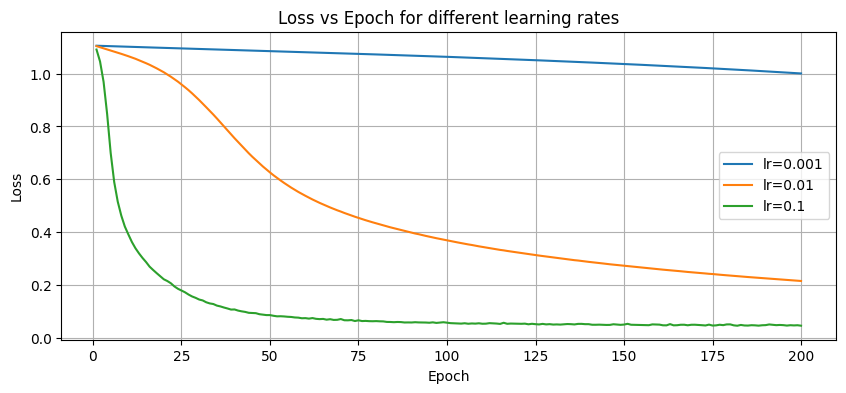

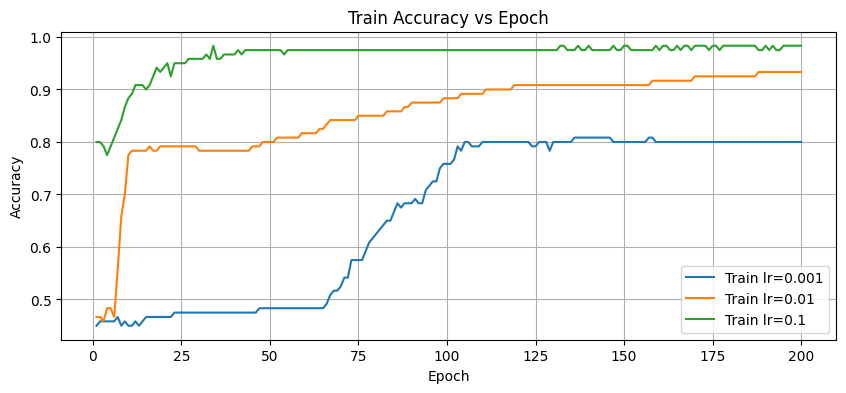

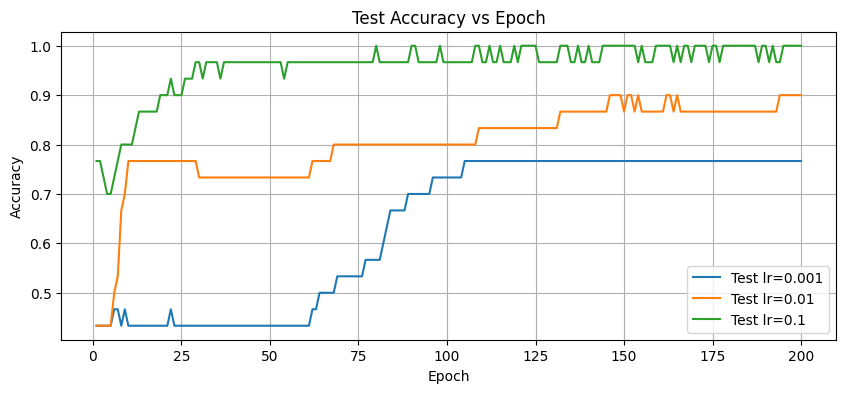

In [5]:
# 5. Experiments with different learning rates

learning_rates = [0.001, 0.01, 0.1]
results = {}

for lr in learning_rates:
    print("Training with learning rate =", lr)
    history = train_mlp(learning_rate=lr, epochs=200, batch_size=16, hidden_dim=16, seed=42)
    results[lr] = history

# 6. Plots: Loss vs Epoch and Accuracy vs Epoch

epochs = np.arange(1, 201)

# Loss vs epoch
plt.figure(figsize=(10, 4))
for lr in learning_rates:
    plt.plot(epochs, results[lr]["losses"], label=f"lr={lr}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch for different learning rates")
plt.legend()
plt.grid(True)
plt.show()

# Train accuracy vs epoch
plt.figure(figsize=(10, 4))
for lr in learning_rates:
    plt.plot(epochs, results[lr]["train_acc"], label=f"Train lr={lr}")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train Accuracy vs Epoch")
plt.legend()
plt.grid(True)
plt.show()

# Test accuracy vs epoch
plt.figure(figsize=(10, 4))
for lr in learning_rates:
    plt.plot(epochs, results[lr]["test_acc"], label=f"Test lr={lr}")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Test Accuracy vs Epoch")
plt.legend()
plt.grid(True)
plt.show()


In [6]:
# 7. Final metrics table (print)

print("\nFinal metrics (last epoch):")
print("LR\tTrain Acc\tTest Acc")
for lr in learning_rates:
    train_acc = results[lr]["train_acc"][-1]
    test_acc = results[lr]["test_acc"][-1]
    print(f"{lr}\t{train_acc:.3f}\t\t{test_acc:.3f}")


Final metrics (last epoch):
LR	Train Acc	Test Acc
0.001	0.800		0.767
0.01	0.933		0.900
0.1	0.983		1.000


## 5. Results

The **Loss vs Epoch** plot shows how quickly and how smoothly the training loss decreases for each learning rate.

Typical expected behavior:

- Very small learning rate (0.001):  
  - Loss decreases slowly but steadily.  
  - Training is stable but convergence is slower.  

- Medium learning rate (0.01):  
  - Loss decreases faster and reaches a low value.  
  - Training is usually stable and efficient.  

- Large learning rate (0.1):  
  - Loss may decrease quickly at first, but can fluctuate more or even increase in some epochs if steps are too large.  
  - Training may be less stable, but still can work on a simple dataset like Iris.

The **Train Accuracy vs Epoch** and **Test Accuracy vs Epoch** plots show how the model performance evolves on both seen (train) and unseen (test) data over time.

From the final metrics table, we can compare:
- Which learning rate achieves the highest train accuracy.
- Which learning rate achieves the highest test accuracy.
- Whether there is a gap between train and test accuracy (sign of overfitting).

## 6. Analysis & Discussion

**Effect of learning rate**

- With a very small learning rate (0.001), the model updates its weights slowly.  
  - Loss decreases gradually and training is stable.  
  - It may require more epochs to reach high accuracy.  

- With a moderate learning rate (0.01), the model generally converges faster.  
  - Loss drops more quickly in the first epochs and stabilizes at a low value.  
  - Train and test accuracy typically become high and stable, making this a good default choice.  

- With a larger learning rate (0.1), the model takes larger steps in parameter space.  
  - This can cause the loss to fluctuate or occasionally increase.  
  - Training can still succeed, but it may be less stable and more sensitive to initialization and batch ordering.

**Convergence behavior**

- When training converges well:
  - Loss decreases and then levels off.
  - Train and test accuracy curves rise and then flatten near their best values.  

- Signs of potential issues:
  - If loss oscillates or diverges with a high learning rate, the step size is likely too large.
  - If both train and test accuracy remain low even after many epochs, the model may be underfitting (too simple or learning too slowly).

**Bias-variance and overfitting**

- If train accuracy is much higher than test accuracy, the model may be overfitting the training data.
- If both train and test accuracy are similar but low, the model may be underfitting, indicating that we might need more capacity, different features, or more training.

Overall, the medium learning rate (0.01) is expected to provide a good balance between convergence speed and stability on this simple dataset.

## 7. Conclusion

- A simple multilayer perceptron (MLP) with one hidden layer can successfully classify the Iris dataset with high accuracy.  
- Implementing the model from scratch clarifies how forward pass, loss computation, and backpropagation work together in a training loop.  
- The learning rate has a strong impact on convergence: too small is slow, too large can be unstable, and a medium value often works best.  
- Monitoring loss and accuracy over epochs helps diagnose convergence behavior and detect potential overfitting or underfitting.  
- This assignment strengthens intuition about how neural networks adjust their weights using gradients to reduce loss and improve predictions.  
- The same training loop structure can be extended to deeper networks, larger datasets, and more complex tasks.